# ML Distance Formula

**Month 1 — Week 1 · AI & ML Learning Phase**

Source: Codecademy — *Measuring Model Accuracy: Distance Formulas*

---

## Why Distance Matters in Machine Learning

Machine learning is often used to predict numeric values. For example, economic models might try to forecast stock prices, and weather models might try to predict the temperature on a specific day.

Because these models can be incredibly influential, understanding how accurate they are is crucial. We need to know how **"far off"** the model's predictions are from the actual values. This is where the mathematical concept of **distance** comes into play, offering a quantitative measure of a model's accuracy.

### Different Kinds of Distance

Measuring distance may seem straightforward, but in practice there are many different kinds of distance.

Take the problem of measuring the distance between two places in a city:

- **Helicopter:** the shortest distance is just the length of a straight line from point A to point B.
- **Walking:** the shortest distance has to take the structure of city blocks and buildings into account — you have to take turns a helicopter wouldn't.

**Distance depends on context.** The same is true for machine learning models: depending on the model, we might measure the "distance" between our prediction and what actually happens in different ways.

### The three distance measures in this lesson

| Distance | Idea | Common use |
|---|---|---|
| **Euclidean** | Length of a straight line between two points | Most common distance formula |
| **Manhattan** | "City block" distance | Urban planning models |
| **Hamming** | Count of dimensions that differ | Distance between words in NLP / spell checking |

Along the way we get practice with Python lists and math libraries like NumPy and SciPy.

## 1. Representing Points

Before diving into the distance formulas, we need a way to represent points in code.

We use a **list**, where each item represents a **dimension** of the point. The point $(5, 8)$ becomes:

```python
pt1 = [5, 8]
```

Points aren't limited to two dimensions — a five-dimensional point could be `[4, 8, 15, 16, 23]`.

Ultimately we'll write functions that look like `distance([1, 2, 3], [5, 8, 9])`.

> ⚠️ **We can only find the distance between two points if they have the same number of dimensions!**

In [1]:
# Exercise: create points of different dimensions
two_d = [10, 2]
five_d = [30, -1, 50, 0, 2]
four_d = [1, 3, 5, 7]

print("2D point:", two_d)
print("5D point:", five_d)
print("4D point:", four_d)

2D point: [10, 2]
5D point: [30, -1, 50, 0, 2]
4D point: [1, 3, 5, 7]


## 2. Euclidean Distance

**Euclidean Distance** is the most commonly used distance formula. To find the Euclidean distance between two points:

1. Calculate the squared difference between each dimension
2. Add up all of those squared differences
3. Take the square root

$$d = \sqrt{(a_1 - b_1)^2 + (a_2 - b_2)^2 + \ldots + (a_n - b_n)^2}$$

In 2D this is just the **Pythagorean theorem** — the straight-line distance is the hypotenuse of a right triangle whose legs are the differences in each dimension:

![Euclidean distance diagram](ML_Distance_Formula_materials/img_euclidean_distance.png)

$$d = \sqrt{(a_1 - b_1)^2 + (a_2 - b_2)^2}$$

In [2]:
def euclidean_distance(pt1, pt2):
  distance = 0
  for i in range(len(pt1)):
    distance += (pt1[i] - pt2[i]) ** 2
  return distance ** 0.5

print(euclidean_distance([1, 2], [4, 0]))
print(euclidean_distance([5, 4, 3], [1, 7, 9]))

3.605551275463989
7.810249675906654


> 💡 **Why can't we find the distance between `[2, 3, 4]` and `[1, 2]`?**
>
> The points have a different number of dimensions — there's no third value in the second point to subtract from the `4`.

## 3. Manhattan Distance

**Manhattan Distance** is extremely similar to Euclidean distance. Rather than summing the *squared* difference between each dimension, we sum the **absolute value** of the difference between each dimension.

It's called Manhattan distance because it's like navigating city blocks: *"how many blocks will it take me to get from point A to point B?"*

$$d = |a_1 - b_1| + |a_2 - b_2| + \ldots + |a_n - b_n|$$

> 📌 **Manhattan distance will always be greater than or equal to Euclidean distance.**

Instead of the straight diagonal line, the path travels along the grid — horizontal then vertical:

![Manhattan distance diagram](ML_Distance_Formula_materials/img_manhattan_distance.png)

$$d = |a_1 - b_1| + |a_2 - b_2|$$

In [3]:
def manhattan_distance(pt1, pt2):
  distance = 0
  for i in range(len(pt1)):
    distance += abs(pt1[i] - pt2[i])
  return distance

# Same points as before — compare with the Euclidean results
print(manhattan_distance([1, 2], [4, 0]))
print(manhattan_distance([5, 4, 3], [1, 7, 9]))

5
13


## 4. Hamming Distance

**Hamming Distance** is another variation on the distance formula. Instead of finding the *difference* of each dimension, Hamming distance only cares about whether the dimensions are **exactly equal**. Add one for every dimension that has different values.

Hamming distance is used in **spell checking algorithms**. For example, the Hamming distance between the word `"there"` and the typo `"thete"` is **1** — each letter is a dimension, and only one dimension differs.

In [4]:
def hamming_distance(pt1, pt2):
  distance = 0
  for i in range(len(pt1)):
    if pt1[i] != pt2[i]:
      distance += 1
  return distance

print(hamming_distance([1, 2], [1, 100]))
print(hamming_distance([5, 4, 9], [1, 7, 9]))

1
2


## 5. SciPy Distances

Now that we've written all three distance formulas ourselves, here's how to use them from Python's **SciPy** library:

| Our function | SciPy equivalent |
|---|---|
| `euclidean_distance()` | `distance.euclidean()` |
| `manhattan_distance()` | `distance.cityblock()` |
| `hamming_distance()` | `distance.hamming()` |

Two noteworthy details:

1. SciPy's Manhattan distance is called **`cityblock()`** — how many blocks away are you?
2. SciPy's Hamming distance is **normalized**: it always returns a number between 0 and 1. It sums the differing dimensions and then **divides by the total number of dimensions**. So where our `hamming_distance([1, 2, 3], [7, 2, -10])` returns `2`, SciPy's version returns `2/3`.

In [5]:
from scipy.spatial import distance

# Our implementations
print(euclidean_distance([1, 2], [4, 0]))
print(manhattan_distance([1, 2], [4, 0]))
print(hamming_distance([5, 4, 9], [1, 7, 9]))

print()

# SciPy implementations
print(distance.euclidean([1, 2], [4, 0]))
print(distance.cityblock([1, 2], [4, 0]))
print(distance.hamming([5, 4, 9], [1, 7, 9]))  # normalized: 2 differences / 3 dimensions

3.605551275463989
5
2

3.605551275463989
5
0.6666666666666666


### Visualizing Euclidean vs Manhattan

A quick plot of both paths between $(1, 2)$ and $(4, 0)$ — the straight hypotenuse vs the city-block route:

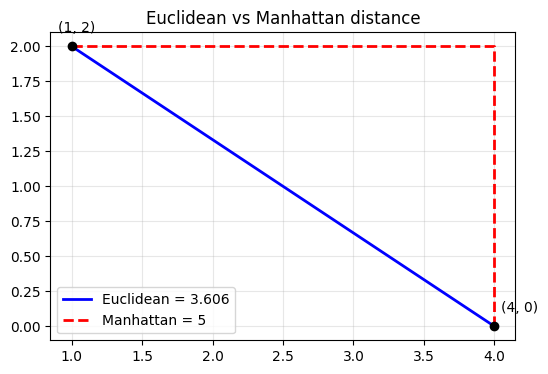

In [6]:
import matplotlib.pyplot as plt

a, b = [4, 0], [1, 2]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([b[0], a[0]], [b[1], a[1]], 'b-', linewidth=2,
        label=f'Euclidean = {euclidean_distance(a, b):.3f}')
ax.plot([b[0], a[0], a[0]], [b[1], b[1], a[1]], 'r--', linewidth=2,
        label=f'Manhattan = {manhattan_distance(a, b)}')
ax.plot(*b, 'ko')
ax.plot(*a, 'ko')
ax.annotate('(1, 2)', b, textcoords='offset points', xytext=(-10, 10))
ax.annotate('(4, 0)', a, textcoords='offset points', xytext=(5, 10))
ax.set_title('Euclidean vs Manhattan distance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---

## 6. Article: Training Set vs Validation Set vs Test Set

*The importance of splitting a data set into training, validation and test sets.*

### Testing Our Model

Supervised machine learning algorithms are amazing tools capable of making predictions and classifications. However, it is important to ask how accurate those predictions are — it's possible that *every* prediction your classifier makes is actually wrong! Luckily, supervised ML algorithms, by definition, have a dataset of **pre-labeled datapoints**. To test the effectiveness of an algorithm, we split this data into:

- **training set**
- **validation set**
- **test set**

### Training Set vs Validation Set

The **training set** is the data the algorithm learns from. Learning looks different depending on the algorithm:

- *Linear Regression*: the training points are used to draw the line of best fit.
- *K-Nearest Neighbors*: the training points are the points that could be the neighbors.

After training, the points in the **validation set** are used to compute the accuracy or error of the classifier. The key insight: we *know* the true labels of every point in the validation set, but we temporarily pretend we don't. We feed each validation point to the classifier, get its prediction, then peek at the true label to see whether it was right. Doing this for every point gives us the **validation error**.

Validation error isn't the only metric — a better way of judging effectiveness is to compute **precision, recall, and F1 score**.

### How to Split

- Training set too small → the algorithm might not have enough data to learn effectively.
- Validation set too small → accuracy, precision, recall, and F1 could have large variance (a lucky or unlucky split).

> 📌 In general, **80% training / 20% validation** is a good place to start.

### N-Fold Cross-Validation

Sometimes the dataset is so small that an 80/20 split still has large variance. The solution: do the whole process **N times and average the accuracy**.

In **10-fold cross-validation**, the validation set is first the first 10% of the data, then the second 10%, and so on — 10 different chunks. Averaging all the accuracies gives a much better sense of how the model does on average.

### Changing The Model / Test Set

Knowing your model's accuracy lets you **tune its parameters** — e.g., in K-Nearest Neighbors, watch what happens to accuracy as you increase or decrease K.

Once you're happy with the model's performance, you introduce the **test set** — the part of the data partitioned away at the very start of the experiment. It's a substitute for real-world data, and you **never touched it while building or tuning the model**. Computing accuracy, precision, recall, and F1 on the test set tells you how the algorithm will do in the real world.

In [7]:
# Quick illustration of an 80/20 train/validation split (plus a held-out test set)
data = list(range(1, 101))  # pretend dataset of 100 labeled points

test_set = data[90:]        # 10% held out at the very start — don't touch until the end!
remaining = data[:90]

split = int(len(remaining) * 0.8)
training_set = remaining[:split]
validation_set = remaining[split:]

print(f"Training set:   {len(training_set)} points")
print(f"Validation set: {len(validation_set)} points")
print(f"Test set:       {len(test_set)} points (untouched until the model is final)")

Training set:   72 points
Validation set: 18 points
Test set:       10 points (untouched until the model is final)


---

## Key Takeaways

1. **Distance quantifies model accuracy** — how "far off" predictions are from actual values. Which distance to use depends on context.
2. **Euclidean distance** = straight-line distance: $\sqrt{\sum (a_i - b_i)^2}$. The most common formula.
3. **Manhattan distance** = city-block distance: $\sum |a_i - b_i|$. Always ≥ Euclidean distance.
4. **Hamming distance** = count of dimensions that differ. Used in spell checking / NLP.
5. **SciPy** provides all three: `distance.euclidean()`, `distance.cityblock()`, `distance.hamming()` — but SciPy's Hamming is *normalized* (divides by the number of dimensions).
6. Points must have the **same number of dimensions** to compute a distance.
7. Split labeled data into **training / validation / test** sets (80/20 train/validation is a good start; use N-fold cross-validation for small datasets; keep the test set untouched until the model is final).